# Flight Fare Price Prediction

## Project Lifecyle
- Business Problem Underswtanding
- Data Collection
- Data Understanding
- Data Pre-processing
- Exploratory Data Analysis(EDA)
- Model Selection
- Model Training
- Prediction
- Model Deployment
- Model Maitainance

### Data Pre-processing
- Null Values (Remove/Replace)
- Duplicate Entries (Remove)
- Data Type
- Outliers
- Feature Engineering
- Scaling
- Encoding (Categorical to Numeric Transformation)


In [2]:
# Importing libraries
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv(r"B:\Training\Summer_Training_2024\Flight_Fare_Prediction\Flight_Data.csv", low_memory = False)
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,date
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,01-01-2018
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,02-01-2018
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,03-01-2018
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,04-01-2018
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,05-01-2018


In [6]:
df = data.copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301206 entries, 0 to 301205
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        301206 non-null  int64  
 1   airline           300754 non-null  object 
 2   flight            301206 non-null  object 
 3   source_city       301206 non-null  object 
 4   departure_time    301206 non-null  object 
 5   stops             301206 non-null  object 
 6   arrival_time      301206 non-null  object 
 7   destination_city  301206 non-null  object 
 8   class             301006 non-null  object 
 9   duration          300956 non-null  float64
 10  days_left         301206 non-null  int64  
 11  price             301106 non-null  object 
 12  date              358 non-null     object 
dtypes: float64(1), int64(2), object(10)
memory usage: 29.9+ MB


#### Conclusion:
- 'Unnamed: 0', 'date' columns can be dropped
- 'price' data type is to be changed

In [8]:
df.isnull().sum()

Unnamed: 0               0
airline                452
flight                   0
source_city              0
departure_time           0
stops                    0
arrival_time             0
destination_city         0
class                  200
duration               250
days_left                0
price                  100
date                300848
dtype: int64

#### Drop Null values if the feature has leass than 1% Null values

In [11]:
# Duplicate Entries
df[df.duplicated()].shape

(0, 13)

#### Conclusion: No duplicate entries are present

In [13]:
# Outliers
df.describe()

,Unnamed: 0,duration,days_left
count,3.012060e+05,300956.000000,301206.000000
mean,1.522690e+05,12.235845,26.042277
std,9.861746e+04,7.298074,13.564973
min,0.000000e+00,0.830000,1.000000
25%,7.530125e+04,6.830000,15.000000
50%,1.506025e+05,11.250000,26.000000
75%,2.259038e+05,16.170000,38.000000
max,1.300222e+06,622.250000,49.000000


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

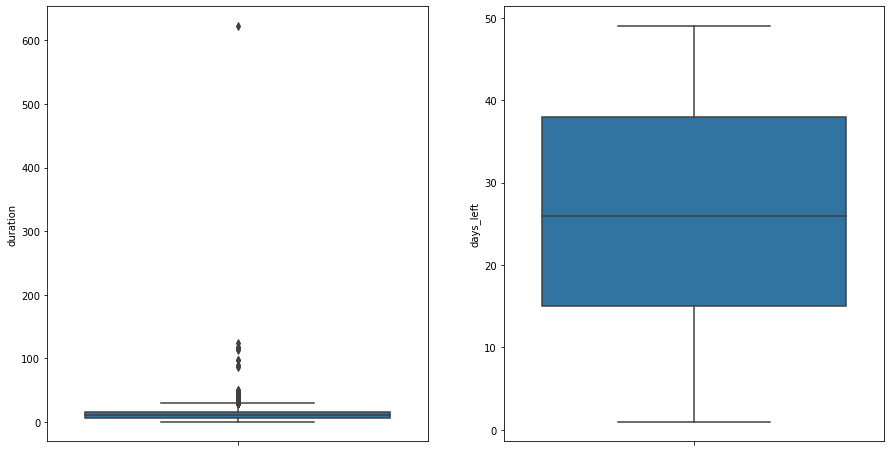

In [19]:
# Outlier Visualization
fig, ax = plt.subplots(1,2, figsize = (15,8))
sns.boxplot(y = 'duration', data = df, ax = ax[0])
sns.boxplot(y = 'days_left', data = df, ax = ax[1])
plt.show()

#### Conclusion:
- 'duration column has outliers, which are to be removed
- Before this, change the data type of 'price' column and do check outliers
